In [9]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
# 1. Read the reservoirs.csv file using Pandas 
df = pd.read_csv("reservoirs.csv")

# 2. Rename headers to English and understandable.
df.columns = [
    'date',
    'area type',
    'area number',
    'year (ISO)',
    'week (ISO)',
    'reservoir level',
    'capacity (TWh)',
    'level (TWh)',
    'next publishing date',
    'reservoir level last week',
    'change level'
]

# 3. Print its contents in a relevant way.
display(df.head())

,date,area type,area number,year (ISO),week (ISO),reservoir level,capacity (TWh),level (TWh),next publishing date,reservoir level last week,change level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


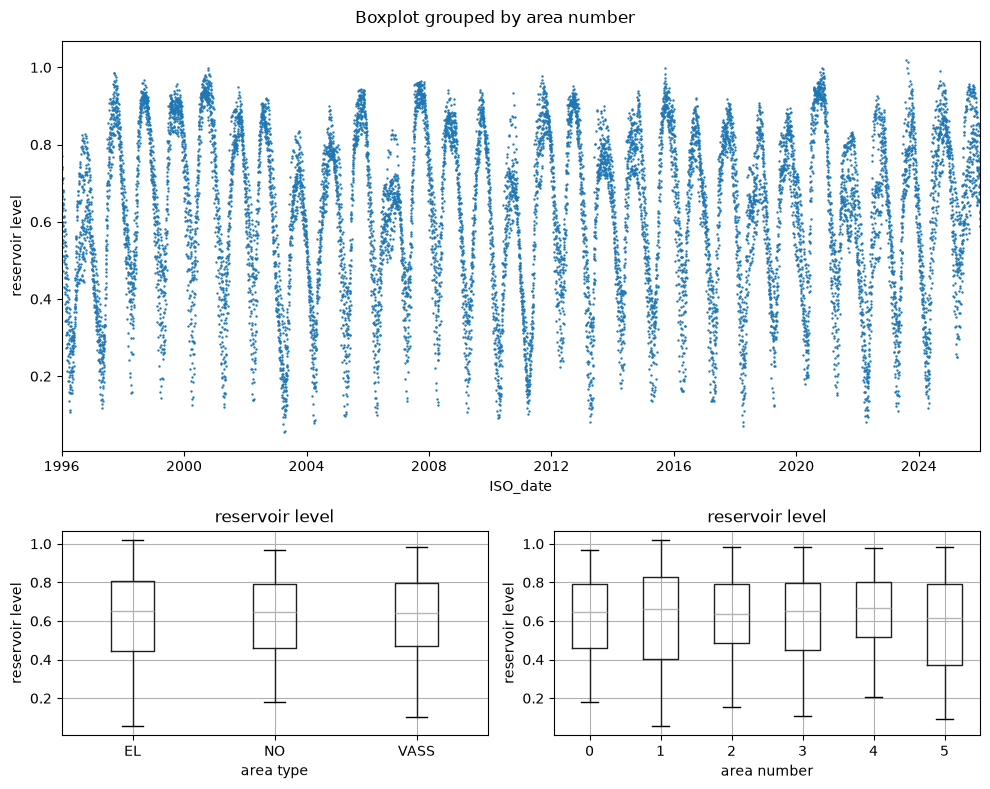

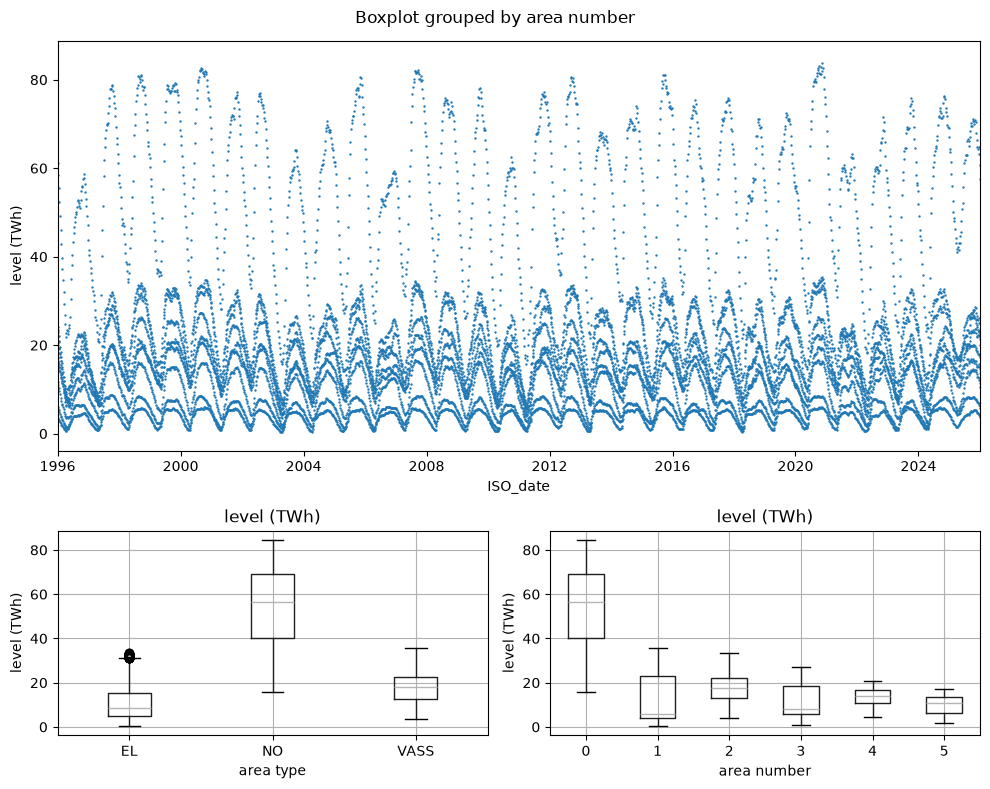

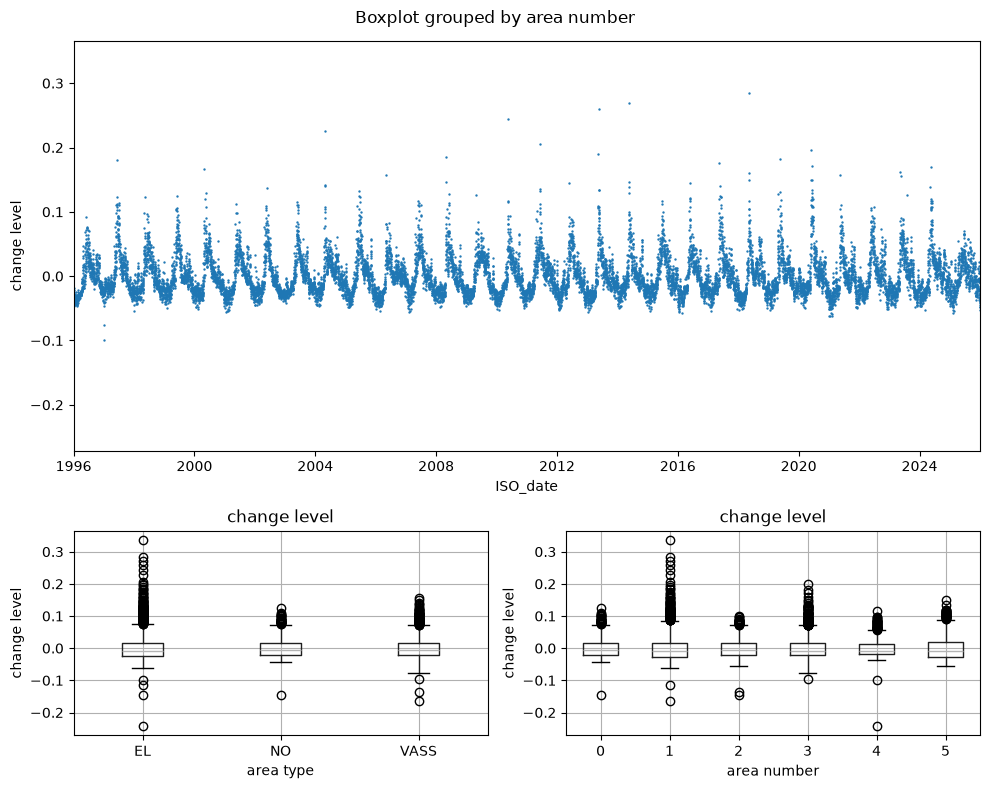

In [ ]:
#Plot all columns separately 
df["ISO_date"] = pd.to_datetime(
    df["year (ISO)"].astype(str)
    + "-W"
    + df["week (ISO)"].astype(str)
    + "-1",
    format="%G-W%V-%u"
)

x_axis_cols = [
    "ISO_date", 
    "area type", 
    "area number"
    ] 

y_axis_cols = [    
    'reservoir level',
    'level (TWh)',
    'change level'
    ]

for col in y_axis_cols: 
    fig = plt.figure(figsize=(10, 8))

    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

    # Big plot for ISO_date
    ax = fig.add_subplot(gs[0, :])
    ax.scatter(df["ISO_date"], df[col], s=0.5)
    ax.set_xlabel("ISO_date")
    ax.set_ylabel(col)
    ax.set_xlim(pd.Timestamp("1996-01-01"), 
                pd.Timestamp("2026-01-01"))

    # Small plot for area type
    ax = fig.add_subplot(gs[1, 0])
    df.boxplot(column=col, by='area type', ax=ax)
    ax.set_xlabel("area type")
    ax.set_ylabel(col)

    # Small plot for area number
    ax = fig.add_subplot(gs[1, 1])
    df.boxplot(column=col, by='area number', ax=ax)
    ax.set_xlabel("area number")
    ax.set_ylabel(col)

    plt.tight_layout()

    plt.show()

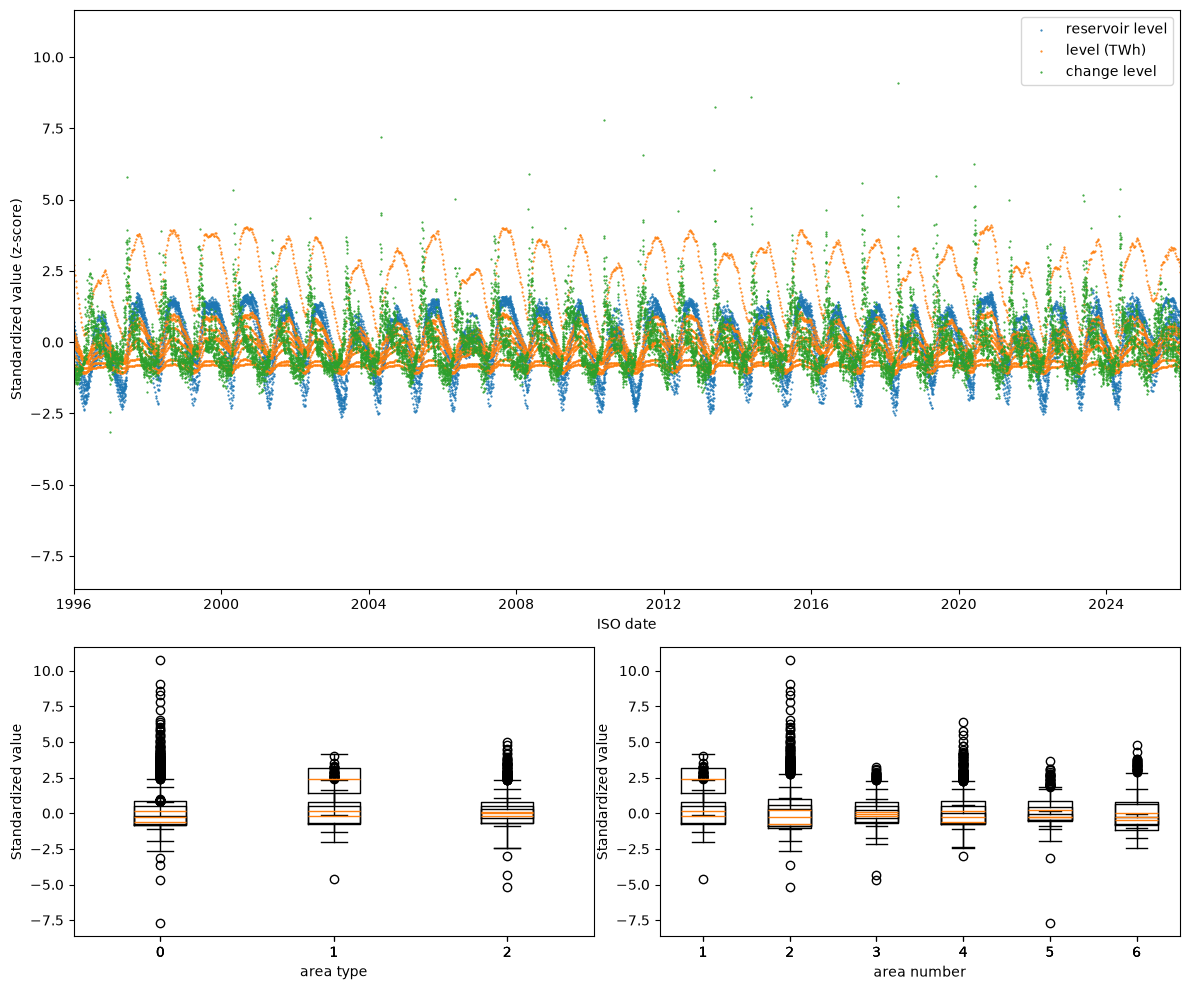

In [5]:
# Plotting all columns together 


# Standardize each variable separately
df_scaled = df.copy()
df_scaled[y_axis_cols] = StandardScaler().fit_transform(df[y_axis_cols])

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# 1. All variables over time
ax = fig.add_subplot(gs[0, :])

for col in y_axis_cols:
    ax.scatter(
        df_scaled["ISO_date"],
        df_scaled[col],
        s=0.3,
        label=col
    )
    ax.set_xlim(pd.Timestamp("1996-01-01"), 
                pd.Timestamp("2026-01-01"))

ax.set_xlabel("ISO date")
ax.set_ylabel("Standardized value (z-score)")
ax.legend()


# 2. All variables by area type
ax = fig.add_subplot(gs[1, 0])

for i, col in enumerate(y_axis_cols):
    data = [
        group[col].dropna()
        for _, group in df_scaled.groupby("area type")
    ]

    # offset positions so boxplots don't overlap
    positions = range(len(data))
    ax.boxplot(data, positions=positions)

ax.set_xlabel("area type")
ax.set_ylabel("Standardized value")


# 3. All variables by area number
ax = fig.add_subplot(gs[1, 1])

for col in y_axis_cols:
    data = [
        group[col].dropna()
        for _, group in df_scaled.groupby("area number")
    ]

    ax.boxplot(data)

ax.set_xlabel("area number")
ax.set_ylabel("Standardized value")

plt.tight_layout()
plt.show()